## This notebook trains an SBERT model on the QQP Dataset

In [1]:
#Importing required packages
import os
import sys
import time
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sys.path.append(os.path.abspath(".."))

from src.sbert_models import (
    load_sbert_model,
    generate_embeddings,
    concatenate_embeddings
)

from src.classical_models import (
    train_logistic_regression,
    predict
)

from src.evaluate import (
    evaluate_classifier,
    compute_confusion_matrix
)

from src.utils import log_experiment

In [17]:
#Load the processed datasets
train = pd.read_csv(
    "../datasets/processed/classical/qqp_train.csv"
)

validation = pd.read_csv(
    "../datasets/processed/classical/qqp_validation.csv"
)

test = pd.read_csv(
    "../datasets/processed/classical/qqp_test.csv"
)

In [18]:
#Loading sbert
model = load_sbert_model()
print(model)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [ ]:
#Generate embeddings
train_emb1 = generate_embeddings(
    model,
    train["question1"]
)

train_emb2 = generate_embeddings(
    model,
    train["question2"]
)

test_emb1 = generate_embeddings(
    model,
    test["question1"]
)

test_emb2 = generate_embeddings(
    model,
    test["question2"]
)

validation_emb1 = generate_embeddings(
    model,
    validation["question1"]
)

validation_emb2 = generate_embeddings(
    model,
    validation["question2"]
)

Batches:   0%|          | 0/1544 [00:00<?, ?it/s]

In [5]:
#Concatenate
X_train = concatenate_embeddings(
    train_emb1,
    train_emb2
)

X_validation = concatenate_embeddings(
    validation_emb1,
    validation_emb2
)

X_test = concatenate_embeddings(
    test_emb1,
    test_emb2
)

print(X_train.shape)

(363846, 768)


In [6]:
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [7]:
#Training a logistic regression model
start_time = time.perf_counter()

classifier = train_logistic_regression(
    X_train,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 36.0282 seconds


In [8]:
#Predictions
start_time = time.perf_counter()

predictions, probabilities = predict(
    classifier,
    X_validation
)

end_time = time.perf_counter()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.1548 seconds


In [9]:
#Evaluation
metrics = evaluate_classifier(
    y_validation,
    predictions,
    probabilities
)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7175
Precision: 0.6625
Recall: 0.4742
F1: 0.5527
ROC-AUC: 0.7504


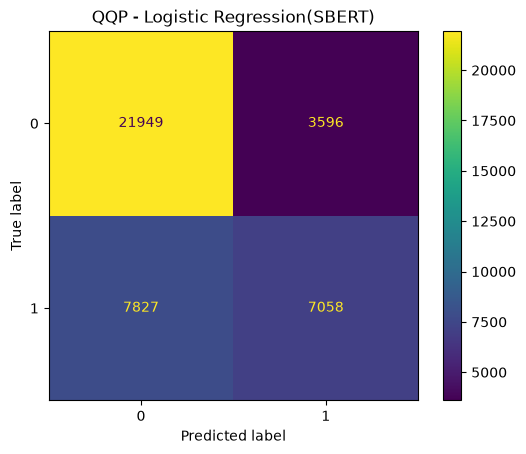

In [10]:
cm = compute_confusion_matrix(
    y_validation,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("QQP - Logistic Regression(SBERT)")

plt.savefig(
    "../results/plots/qqp_confusion_matrix(SBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

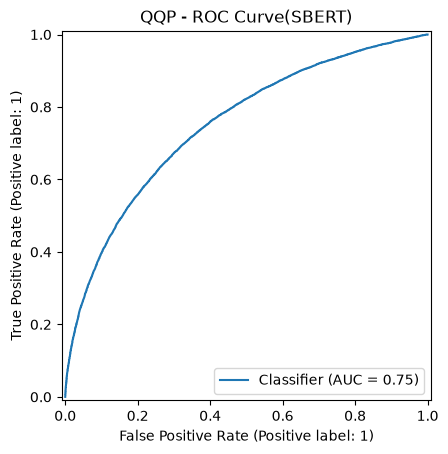

In [11]:
RocCurveDisplay.from_predictions(
    y_validation,
    probabilities
)

plt.title("QQP - ROC Curve(SBERT)")

plt.savefig(
    "../results/plots/qqp_roc_curve(SBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
#Saving the results
predictions_df = validation.copy()

predictions_df["prediction"] = predictions
predictions_df["probability"] = probabilities

predictions_df.to_csv(
    "../results/predictions/qqp_predictions(SBERT).csv",
    index=False
)

predictions_df.head()

,question1,question2,label,idx,prediction,probability
0,why are african-americans so beautiful?,why are hispanics so beautiful?,0,0,0,0.155495
1,i want to pursue phd in computer science about...,i handle social media for a non-profit. should...,0,1,0,0.044907
2,is there a reason why we should travel alone?,what are some reasons to travel alone?,1,2,1,0.583792
3,why are people so obsessed with having a girlf...,how can a single male have a child?,0,3,0,0.364624
4,what are some good baby girl names starting wi...,what are some good baby girl names starting wi...,0,4,0,0.059105


In [13]:
#Saving the predictions
metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../results/metrics/qqp_logreg_metrics(SBERT).csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.717462,0.662474,0.474169,0.552723,0.750352


In [14]:
#Saving the model
from src.utils import save_model

save_model(
    classifier,
    "../models/sbert/qqp_classifier.pkl"
)

In [15]:
from datetime import date
from src.utils import log_experiment

experiment = {
    "Experiment ID": "EXP-004",
    "Date": date.today().isoformat(),
    "Phase": "SBERT Baseline",
    "Model": "SBERT + Logistic Regression",
    "Dataset": "QQP",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": 32,
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "all-MiniLM-L6-v2 (384d), concatenated embeddings",
    "Status": "Completed"
}

log_experiment(
    "../logs/experiments.xlsx",
    experiment
)

In [16]:
from src.reporting import ReportGenerator

report = ReportGenerator()

comparison = report.generate_model_comparison()

comparison

,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time,Inference Time
0,Logistic Regression,MRPC,0.727941,0.723404,0.974910,0.830534,0.675863,0.036566,0.000996
2,Logistic Regression,PAWS,0.556500,0.497691,0.274089,0.353499,0.548097,0.695119,0.009175
1,Logistic Regression,QQP,0.767549,0.722849,0.597850,0.654434,0.836436,3.161926,0.008341
3,SBERT + Logistic Regression,MRPC,0.629902,0.720690,0.749104,0.734622,0.561279,0.793760,0.003465
4,SBERT + Logistic Regression,QQP,0.717462,0.662474,0.474169,0.552723,0.750352,36.028248,0.154764
